# Q13.
```{admonition}
:class: note
There is a gene expression data set (`Ch12Ex13.csv`) that consists of $40$ tissue samples with measurements on $1\,000$ genes. The first $20$ samples are from healthy patients, while the second $20$ are from a diseased group.

In [2]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
from scipy.cluster.hierarchy import cut_tree, dendrogram
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [4]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

In [5]:
def get_linkage_matrix(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    return linkage_matrix

## (a)
```{admonition}
:class: note
Load in the data using `pd.read_csv()`. You will need to select `header = None`.

In [6]:
gene = pd.read_csv('../../ALL CSV FILES - 2nd Edition/Ch12Ex13.csv',header=None).T
true_class = [0]*20+[1]*20

In [7]:
gene.head(3)

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,-0.961933,-0.292526,0.258788,-1.152132,0.195783,0.030124,0.085418,1.116610,-1.218857,1.267369,...,1.325041,-0.116171,-1.470146,-0.379272,-1.465006,1.075148,-1.226125,-3.056328,1.450658,0.717977
1,0.441803,-1.139267,-0.972845,-2.213168,0.593306,-0.691014,-1.113054,1.341700,-1.277279,-0.918349,...,0.740838,-0.162392,-0.633375,-0.895521,2.034465,3.003267,-0.501702,0.449889,1.310348,0.763482
2,-0.975005,0.195837,0.588486,-0.861525,0.282992,-0.403426,-0.677969,0.103278,-0.558925,-1.253500,...,-0.435533,-0.235912,1.446660,-1.127459,0.440849,-0.123441,-0.717430,1.880362,0.383837,0.313576


## (b)
```{admonition}
:class: note
Apply hierarchical clustering to the samples using correlation-based distance, and plot the dendrogram. Do the genes separate the samples into the two groups? Do your results depend on the type of linkage used?

In [8]:
linkages = ['complete','average','single']
clusters_unscaled = {}
corr_dist = 1-np.corrcoef(gene)

for linkage in linkages:
    gene_cluster_full = AgglomerativeClustering(distance_threshold=0,n_clusters=None,metric='precomputed',linkage=linkage)
    gene_cluster_two = AgglomerativeClustering(n_clusters=2,metric='precomputed',linkage=linkage)

    gene_cluster_full.fit(corr_dist)
    gene_cluster_two.fit(corr_dist)
    
    link_matrix = get_linkage_matrix(gene_cluster_full)
    
    clusters_unscaled[linkage] = {'matrix':link_matrix,
                         'cut':np.mean([link_matrix[-1,2],link_matrix[-2,2]]),
                         'labels':gene_cluster_two.labels_,
                         'ari':adjusted_rand_score(true_class,gene_cluster_two.labels_)
                        }

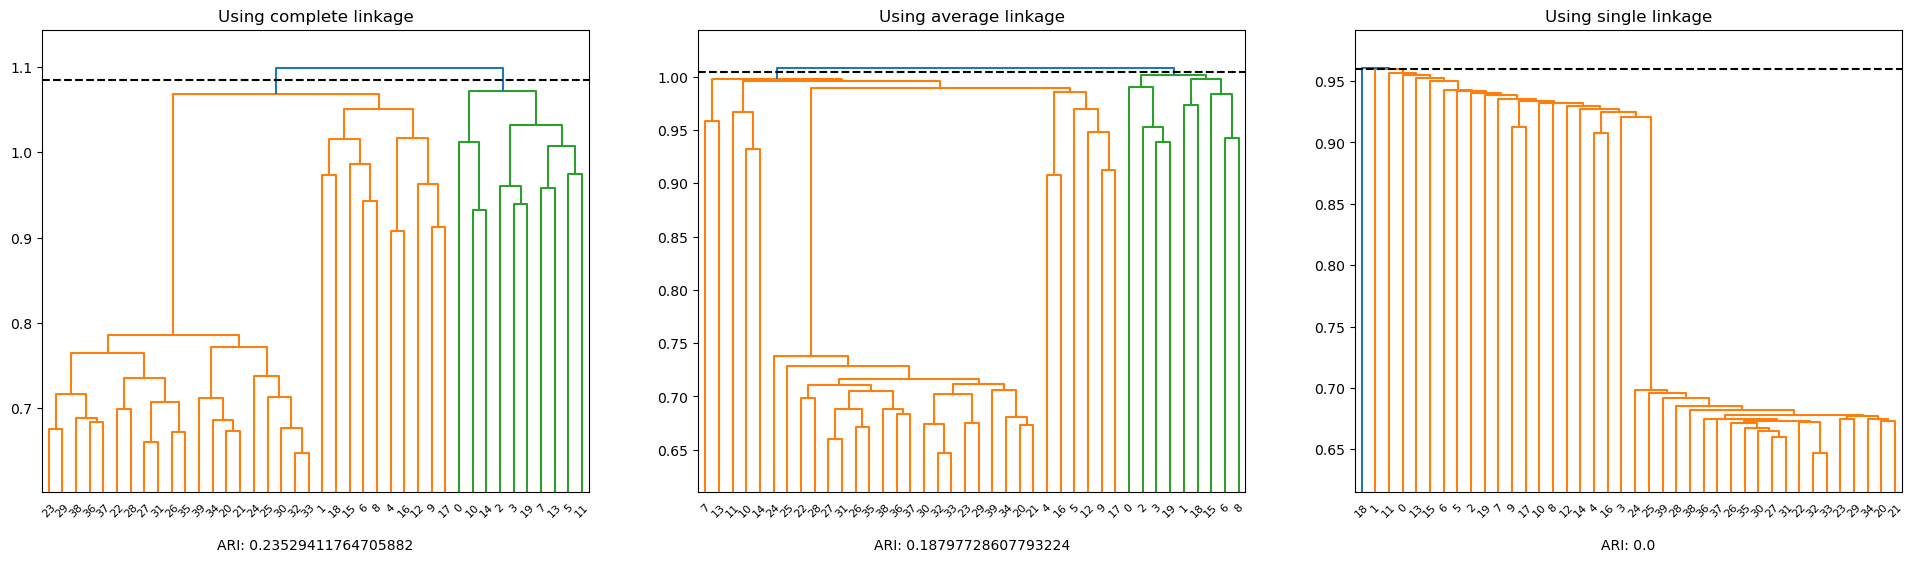

In [9]:
fig, ax = plt.subplots(1,3,figsize=(24,6))
ax = ax.flatten()
for i, linkage in enumerate(clusters_unscaled):
    current = clusters_unscaled[linkage]
    upper = current['matrix'][-1,2]
    lower = current['matrix'][0,2]
    margin = (upper-lower)*0.1
    
    dendrogram(current['matrix'],color_threshold=current['cut'],ax=ax[i]);
    ax[i].hlines(current['cut'],*ax[i].get_xlim(),color='k',linestyles='dashed')
    ax[i].set_ylim([lower-margin,upper+margin])
    ax[i].set_title(f'Using {linkage} linkage')
    ax[i].text(0.5,-0.1,f'ARI: {current['ari']}',ha='center',va='top',transform=ax[i].transAxes)

In [10]:
gene_scaled = StandardScaler().fit_transform(gene)
clusters_scaled = {}
corr_dist_sc = 1-np.corrcoef(gene_scaled)

for linkage in linkages:
    gene_cluster_full = AgglomerativeClustering(distance_threshold=0,n_clusters=None,metric='precomputed',linkage=linkage)
    gene_cluster_two = AgglomerativeClustering(n_clusters=2,metric='precomputed',linkage=linkage)

    gene_cluster_full.fit(corr_dist_sc)
    gene_cluster_two.fit(corr_dist_sc)
    
    link_matrix = get_linkage_matrix(gene_cluster_full)
    
    clusters_scaled[linkage] = {'matrix':link_matrix,
                         'cut':np.mean([link_matrix[-1,2],link_matrix[-2,2]]),
                         'labels':gene_cluster_two.labels_,
                         'ari':adjusted_rand_score(true_class,gene_cluster_two.labels_)
                        }

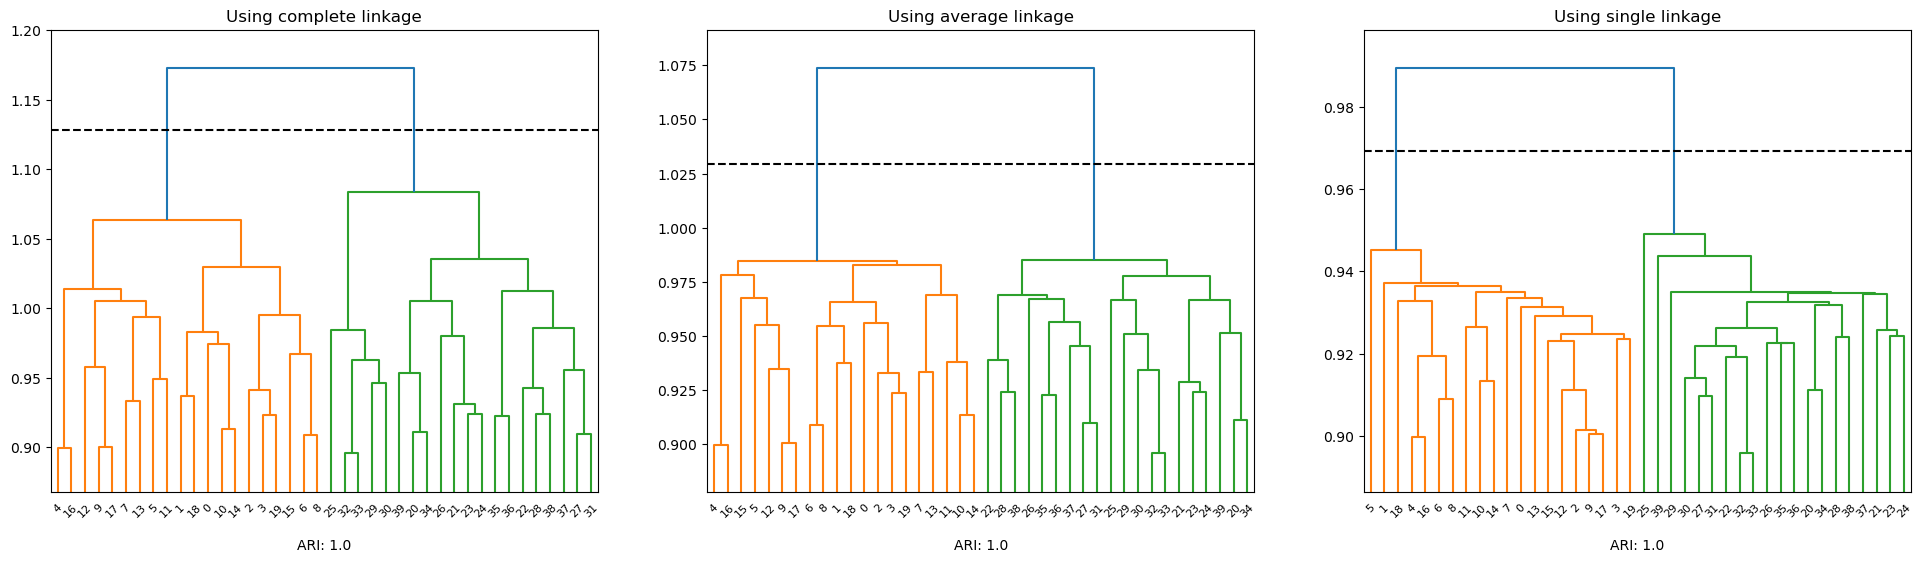

In [11]:
fig, ax = plt.subplots(1,3,figsize=(24,6))
ax = ax.flatten()
for i, linkage in enumerate(clusters_scaled):
    current = clusters_scaled[linkage]
    upper = current['matrix'][-1,2]
    lower = current['matrix'][0,2]
    margin = (upper-lower)*0.1
    
    dendrogram(current['matrix'],color_threshold=current['cut'],ax=ax[i]);
    ax[i].hlines(current['cut'],*ax[i].get_xlim(),color='k',linestyles='dashed')
    ax[i].set_ylim([lower-margin,upper+margin])
    ax[i].set_title(f'Using {linkage} linkage')
    ax[i].text(0.5,-0.1,f'ARI: {current['ari']}',ha='center',va='top',transform=ax[i].transAxes)

## (c)
```{admonition}
:class: note
Your collaborator wants to know which genes differ the most across the two groups. Suggest a way to answer this question, and apply it here.

We can use PCA to determine variation among the groups. Alternatively, we could look at the means of each gene per group and see if they are statistically different after adjusting for the multiple tests being done.

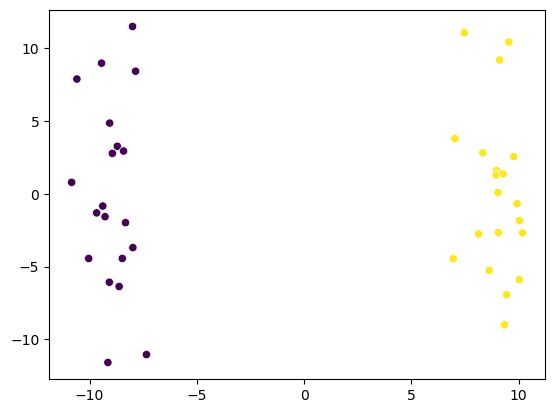

In [12]:
pca = PCA()
pca.fit(gene_scaled)
scores = pca.transform(gene_scaled)

sns.scatterplot(x=scores[:,0], y=scores[:,1],c=true_class)
plt.show()

In [13]:
np.argsort(np.abs(pca.components_[0]))[-10:]

array([508, 583, 537, 592, 550, 599, 589, 564, 588, 501])

In [14]:
healthy = gene.iloc[:20]
disease = gene.iloc[20:]
pvals = []

for g in gene.columns:
    _, p_val = ttest_ind(healthy[g],disease[g],equal_var=False)
    pvals.append(p_val)

In [15]:
pd.DataFrame(multipletests(pvals,alpha=0.20,method='fdr_bh')[1],columns=['p value']).sort_values(by='p value').head(10).T

,501,588,599,589,564,592,550,583,537,568
p value,1.530472e-09,3.255932e-09,3.345330e-09,2.808639e-08,3.531728e-08,1.928742e-07,1.928742e-07,2.665763e-07,2.830488e-07,2.830488e-07
